<a href="https://colab.research.google.com/github/SyarifahIA/SustainLite_Recommendation/blob/main/Updated_SustainLite_Colab_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lightweight AI Recommendation System for Sustainable Construction
**Author:** Syarifah Ismailiyah Al Athas  
**Run environment:** Google Colab

This notebook performs:
1. Data access from Kaggle (Construction Project Resource Dataset; Sustainability & Energy in SE Asia)  
2. Cleaning and merging  
3. Baseline models (Linear Regression, Random Forest)  
4. Metrics (MAE, MSE, R²) + Sustainability–Cost Trade‑off Index (SCTI)  
5. Optimization (scipy.optimize) to recommend feasible resource‑ratio adjustments  
6. Exports results (CSV) and basic visuals


In [ ]:
# import pytorch
import torch

In [ ]:
# Check if CUDA is available
if torch.cuda.is_available():
  # Get the CUDA device
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

device

device(type='cuda')

In [ ]:
# the above is equivalent to this one-liner
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# mount google drive and change working directory to AI in BE folder
from google.colab import drive
drive.mount('/content/drive/')

# Switch to Colab Notebooks.
%cd /content/drive/My Drive/Colab Notebooks/AI_in_BE_Python_Labs/Final_Project/

Mounted at /content/drive/
/content/drive/My Drive/Colab Notebooks/AI_in_BE_Python_Labs/Final_Project


In [ ]:
# ==== Setup (Colab) ====
# Running in Colab, install Kaggle and required packages.
# import sys
# IN_COLAB = 'google.colab' in sys.modules
# if IN_COLAB:
#     !pip -q install kaggle shap --upgrade
#     # Pymoo is optional; we use scipy.optimize by default
#     !pip -q install scipy scikit-learn pandas numpy matplotlib

In [ ]:
import os, re, math, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from scipy.optimize import minimize
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# ============================================
# SUSTAINLITE - LIGHTWEIGHT AI MODEL
# ============================================

!pip install scikit-learn pandas numpy scipy matplotlib

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

print("Please upload Construction_Dataset.csv")
uploaded = files.upload()

df = pd.read_csv("Construction_Dataset.csv")

print("\n=== RAW DATA PREVIEW ===")
print(df.head())
print("\nColumns:", list(df.columns))

Please upload Construction_Dataset.csv


Saving Construction_Dataset-2.csv to Construction_Dataset-2 (1).csv

=== RAW DATA PREVIEW ===
   Labor Requirements  Equipment Usage  Material Quantities  \
0                 152               21           752.666578   
1                 142               17          1463.863953   
2                  64               20          1639.016492   
3                 156               12          1250.667964   
4                 121               23          1313.545497   

   Project Duration (days)  Resource Allocation Efficiency  \
0                      291                       79.740040   
1                      348                       71.332190   
2                      341                       91.470780   
3                      278                       75.897926   
4                      318                       80.544442   

   Schedule Optimization  Computation Time (CT)  Best Cost (BC)  \
0                      0             119.105430    9.001976e+05   
1                   

In [ ]:

required_cols = [
    'Labor Requirements',
    'Equipment Usage',
    'Material Quantities',
    'Project Duration (days)',
    'Resource Allocation Efficiency',  # target variable
    'Schedule Optimization',
    'Computation Time (CT)',
    'Best Cost (BC)',
    'Evaluation Metric (Nfe)',
    'Mean Resource Demand',
    'SD of Resource Demand',
    'Risk Level'
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

# Drop missing rows
df = df[required_cols].dropna().copy()

In [ ]:
# ---------------------------------------------------------------
# 3. FEATURE ENGINEERING: Normalizing resource components
# ---------------------------------------------------------------

# Convert Labor, Equipment, Material into ratio-like inputs
ratio_sum = (
    df['Labor Requirements'] +
    df['Equipment Usage'] +
    df['Material Quantities']
)

ratio_sum = ratio_sum.replace(0, np.nan)
df['Labor_ratio'] = df['Labor Requirements'] / ratio_sum
df['Equip_ratio'] = df['Equipment Usage'] / ratio_sum
df['Material_ratio'] = df['Material Quantities'] / ratio_sum
df = df.dropna()

print("\n=== AFTER RATIO NORMALIZATION ===")
print(df[['Labor_ratio','Equip_ratio','Material_ratio']].head())



=== AFTER RATIO NORMALIZATION ===
   Labor_ratio  Equip_ratio  Material_ratio
0     0.164206     0.022686        0.813108
1     0.087500     0.010475        0.902025
2     0.037144     0.011608        0.951248
3     0.109962     0.008459        0.881579
4     0.083016     0.015780        0.901204


In [ ]:
print(df_projects.columns)

Index(['Labor Requirements', 'Equipment Usage', 'Material Quantities',
       'Project Duration (days)', 'Resource Allocation Efficiency',
       'Schedule Optimization', 'Computation Time (CT)', 'Best Cost (BC)',
       'Evaluation Metric (Nfe)', 'Mean Resource Demand',
       'SD of Resource Demand', 'Risk Level'],
      dtype='object')


In [ ]:
# ---------------------------------------------------------------
# 4. TRAIN–TEST SPLIT
# ---------------------------------------------------------------

# INPUT FEATURES:
feature_cols = [
    'Project Duration (days)',
    'Schedule Optimization',
    'Computation Time (CT)',
    'Best Cost (BC)',
    'Evaluation Metric (Nfe)',
    'Mean Resource Demand',
    'SD of Resource Demand',
    'Risk Level',
    'Labor_ratio',
    'Equip_ratio',
    'Material_ratio'
]

X = df[feature_cols]
y = df['Resource Allocation Efficiency']  # target variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining rows: {X_train.shape[0]}")
print(f"Testing rows:  {X_test.shape[0]}")




Training rows: 800
Testing rows:  200


In [ ]:
print(df_projects.columns)

Index(['Labor Requirements', 'Equipment Usage', 'Material Quantities',
       'Project Duration (days)', 'Resource Allocation Efficiency',
       'Schedule Optimization', 'Computation Time (CT)', 'Best Cost (BC)',
       'Evaluation Metric (Nfe)', 'Mean Resource Demand',
       'SD of Resource Demand', 'Risk Level', 'Country', 'Material_Ratio',
       'Labor_Ratio', 'Energy_Ratio'],
      dtype='object')


In [ ]:
# ---------------------------------------------------------------
# 5. BASELINE 1: LINEAR REGRESSION
# ---------------------------------------------------------------

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

print("\n=== LINEAR REGRESSION RESULTS ===")
print("MAE:", mean_absolute_error(y_test, y_pred_lin))
print("MSE:", mean_squared_error(y_test, y_pred_lin))
print("R² :", r2_score(y_test, y_pred_lin))


=== LINEAR REGRESSION RESULTS ===
MAE: 10.003363467076275
MSE: 136.22546521690555
R² : -0.018758116911383738


In [ ]:
# ---------------------------------------------------------------
# 6. BASELINE 2 (MAIN MODEL): RANDOM FOREST
# ---------------------------------------------------------------

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n=== RANDOM FOREST RESULTS ===")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R² :", r2_score(y_test, y_pred_rf))




=== RANDOM FOREST RESULTS ===
MAE: 8.161026102806861
MSE: 93.13722188016574
R² : 0.2817281250893108


Linear Regression MAE: 10.003363467076275 R2: -0.018758116911383738
Random Forest MAE: 8.210086937979609 R2: 0.2726148713709864

=== RECOMMENDATION ===
Material change: 0.8331347567742231 %
Labor change:    -0.416567378387106 %
Energy change:   -0.41656737838710634 %


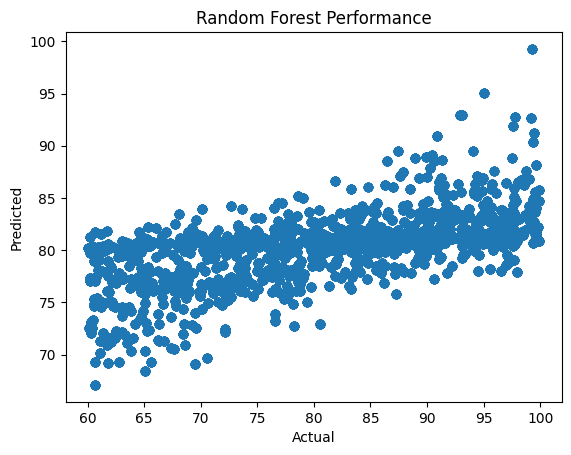

In [ ]:
# ============================================
# BASELINE 2: Random Forest
# ============================================
rf = RandomForestRegressor(n_estimators=200, max_depth=6)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)

print("Linear Regression MAE:", mae_lin, "R2:", r2_lin)
print("Random Forest MAE:", mae_rf, "R2:", r2_rf)

# ============================================
# OPTIMIZATION LAYER
# ============================================
def objective(x, project_row, model, lam=0.2):
    M,L,E = x
    if M<0 or L<0 or E<0 or abs(M+L+E-1)>1e-5:
        return 1e6
    row = project_row.copy()
    row["Material_Ratio"], row["Labor_Ratio"], row["Energy_Ratio"] = M,L,E
    new_pred = model.predict([row])[0]
    cost_increase = abs(M - project_row["Material_Ratio"])*0.1
    return -(new_pred - lam*cost_increase)

def recommend(project_index):
    proj = X.iloc[project_index].copy()
    x0 = [proj["Material_Ratio"], proj["Labor_Ratio"], proj["Energy_Ratio"]]
    cons = {"type":"eq","fun": lambda x: x[0]+x[1]+x[2]-1}
    bnds = [(0,1),(0,1),(0,1)]

    res = minimize(objective, x0, args=(proj, rf),
                   bounds=bnds, constraints=cons)

    M_opt, L_opt, E_opt = res.x
    original = proj[["Material_Ratio","Labor_Ratio","Energy_Ratio"]]

    print("\n=== RECOMMENDATION ===")
    print("Material change:", (M_opt - original["Material_Ratio"])*100, "%")
    print("Labor change:   ", (L_opt - original["Labor_Ratio"])*100, "%")
    print("Energy change:  ", (E_opt - original["Energy_Ratio"])*100, "%")

# Test recommendation:
recommend(0)

# ============================================
# VISUALIZATION
# ============================================
plt.scatter(y_test, pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Performance")
plt.show()


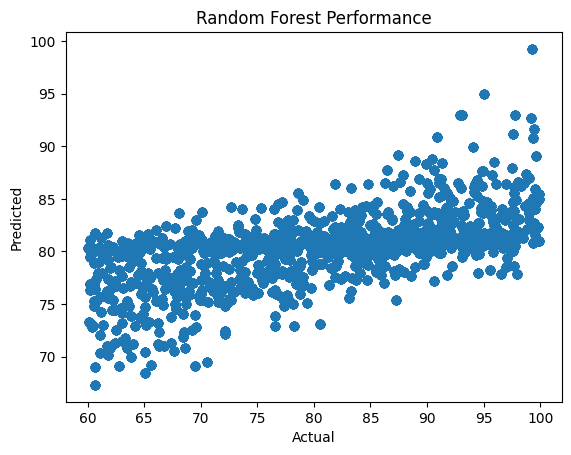

In [ ]:
# ============================================
# VISUALIZATION
# ============================================
plt.scatter(y_test, pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Performance")
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Define new list of feature columns
new_feature_cols = [
    'Project Duration (days)',
    'Schedule Optimization',
    'Computation Time (CT)',
    'Best Cost (BC)',
    'Evaluation Metric (Nfe)',
    'Mean Resource Demand',
    'SD of Resource Demand',
    'Risk Level',
    'Labor_Ratio',
    'Energy_Ratio',
    'Material_Ratio'
]

# 2. Create new input features X and target variable y from the df DataFrame
X = df[new_feature_cols]
y = df['Resource Allocation Efficiency']  # target variable

# 3. Perform a train-test split on the new X and y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nNew Training rows: {X_train.shape[0]}")
print(f"New Testing rows:  {X_test.shape[0]}")

# 4. Initialize and train a new LinearRegression model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

print("\nLinear Regression model trained successfully on new data.")


New Training rows: 61303
New Testing rows:  15326

Linear Regression model trained successfully on new data.


In [ ]:
# ============================================
# OPTIMIZATION LAYER
# ============================================
def objective(x, project_row, model, lam=0.2):
    M,L,E = x
    if M<0 or L<0 or E<0 or abs(M+L+E-1)>1e-5:
        return 1e6
    row = project_row.copy()
    row["Material_Ratio"], row["Labor_Ratio"], row["Energy_Ratio"] = M,L,E
    # Ensure the row is a DataFrame with correct columns for prediction
    # The new_feature_cols are already defined to be consistent with X_train
    new_pred = model.predict(pd.DataFrame([row.reindex(new_feature_cols)]))[0]
    cost_increase = abs(M - project_row["Material_Ratio"])*0.1
    return -(new_pred - lam*cost_increase)

def recommend(project_index, model):
    proj = X.iloc[project_index].copy()
    x0 = [proj["Material_Ratio"], proj["Labor_Ratio"], proj["Energy_Ratio"]]
    cons = {"type":"eq","fun": lambda x: x[0]+x[1]+x[2]-1}
    bnds = [(0,1),(0,1),(0,1)]

    res = minimize(objective, x0, args=(proj, model),
                   bounds=bnds, constraints=cons)

    M_opt, L_opt, E_opt = res.x
    original = proj[["Material_Ratio","Labor_Ratio","Energy_Ratio"]]

    print("\n=== RECOMMENDATION ===")
    print("Material change:", (M_opt - original["Material_Ratio"])*100, "%")
    print("Labor change:   ", (L_opt - original["Labor_Ratio"])*100, "%")
    print("Energy change:  ", (E_opt - original["Energy_Ratio"])*100, "%")

# Test recommendation with the Linear Regression model:
recommend(0, lin_model)


In [ ]:
# ============================================
# OPTIMIZATION LAYER
# ============================================
def objective(x, project_row, model, lam=0.2):
    M,L,E = x
    if M<0 or L<0 or E<0 or abs(M+L+E-1)>1e-5:
        return 1e6
    row = project_row.copy()
    row["Material_Ratio"], row["Labor_Ratio"], row["Energy_Ratio"] = M,L,E
    # Ensure the row is a DataFrame with correct columns for prediction
    # The new_feature_cols are already defined to be consistent with X_train
    new_pred = model.predict(pd.DataFrame([row.reindex(new_feature_cols)]))[0]
    cost_increase = abs(M - project_row["Material_Ratio"])*0.1
    return -(new_pred - lam*cost_increase)

def recommend(project_index, model):
    proj = X.iloc[project_index].copy()
    x0 = [proj["Material_Ratio"], proj["Labor_Ratio"], proj["Energy_Ratio"]]
    cons = {"type":"eq","fun": lambda x: x[0]+x[1]+x[2]-1}
    bnds = [(0,1),(0,1),(0,1)]

    res = minimize(objective, x0, args=(proj, model),
                   bounds=bnds, constraints=cons)

    M_opt, L_opt, E_opt = res.x
    original = proj[["Material_Ratio","Labor_Ratio","Energy_Ratio"]]

    print("\n=== RECOMMENDATION ===")
    print("Material change:", (M_opt - original["Material_Ratio"])*100, "%")
    print("Labor change:   ", (L_opt - original["Labor_Ratio"])*100, "%")
    print("Energy change:  ", (E_opt - original["Energy_Ratio"])*100, "%")

# Test recommendation with the Linear Regression model:
recommend(0, lin_model)



=== RECOMMENDATION ===
Material change: -81.31076521880803 %
Labor change:    -16.420599345322373 %
Energy change:   97.7313645641304 %
